# Charging Behavior and Synthetic Load Generation

This notebook synthesizes an `8760`-hour EV charging load profile from the processed session dataset using:

- **Energy budgeting** from fleet assumptions
- **Stratified bootstrapping** by `Property.Type`, `Charger.Level`, and day type (`weekday`/`weekend`)
- **Constant-power session allocation** into hourly demand
- **Scenario reduction** (daily profile clustering)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

try:
    from sklearn.cluster import KMeans
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 120)

## 1) Inputs and Assumptions

Update these values to match your planning case.

In [2]:
DATA_PATH = Path("intermediate_geolabeled_with_density_category 2.csv")
TUPLE_DATA_PATH = Path("outputs/session_energy_tuples_with_raw_share.csv")

# Planning assumptions (edit as needed)
SIM_YEAR = 2025
PROJECTED_NUM_EVS = 2_500_000
AVG_DAILY_VMT_PER_EV = 35.0
FLEET_EFFICIENCY_KWH_PER_MILE = 0.30

# Threshold (kW) used to flag Level 1 charging sessions for diagnostics and
# plotting. Computed power is energy / duration; typical L1 (120 V) sessions
# are ~1.4-1.9 kW, so 3 kW is a safe split.
# NOTE: this threshold does NOT change the synthesizer's pool keying. The
# residential bucket is a single combined pool (Residential_L1_L2) and L1/L2
# sessions inside it are sampled uniformly per session.
L1_POWER_THRESHOLD_KW = 3.0

# Daily infrastructure allocation shares (your requested mix).
RAW_SHARES = {
    "DCFC": 0.20,
    "Workplace_L2": 0.04,
    "Public_L2": 0.08,
    "Residential_L1_L2": 0.68,
}

# Monte Carlo controls (365-day bootstrap from preprocessed tuple CSV)
N_SCENARIO_YEARS = 1

# Super-session control: each sampled session can represent multiple identical sessions.
# Larger values reduce effective draws and increase daily shape variance.
SUPER_SESSION_FACTOR = 80.0
MIN_TARGET_DRAWS_PER_CATEGORY = 25

# Scenario reduction controls
N_REPRESENTATIVE_DAYS = 12

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"
print(f"Using dataset: {DATA_PATH.resolve()}")
print(f"Tuple output CSV: {TUPLE_DATA_PATH.resolve()}")

Using dataset: E:\GitHub\EV_LCA\intermediate_geolabeled_with_density_category 2.csv
Tuple output CSV: E:\GitHub\EV_LCA\outputs\session_energy_tuples_with_raw_share.csv


## 2) Load and preprocess session-level data

Required labels: `Property.Type`, `Charger.Level`, and day type (`weekday`/`weekend`).

In [3]:
usecols = [
    "StartTime.PST_Converted",
    "EndTime.PST_Converted",
    "Energy.kWh",
    "duration_sec",
    "Property.Type",
    "Charger.Level",
    "GEOID",
]

df = pd.read_csv(DATA_PATH, usecols=usecols, low_memory=False)

# Datetime parsing
df["start_ts"] = pd.to_datetime(df["StartTime.PST_Converted"], errors="coerce")
df["end_ts"] = pd.to_datetime(df["EndTime.PST_Converted"], errors="coerce")

# Fallback if end timestamp is missing but duration exists
missing_end = df["end_ts"].isna() & df["start_ts"].notna() & df["duration_sec"].notna()
df.loc[missing_end, "end_ts"] = df.loc[missing_end, "start_ts"] + pd.to_timedelta(df.loc[missing_end, "duration_sec"], unit="s")

# Basic quality filters
df = df[df["start_ts"].notna() & df["end_ts"].notna()].copy()
df = df[df["Energy.kWh"].notna() & (df["Energy.kWh"] > 0)].copy()

# Duration in hours
df["duration_h"] = (df["end_ts"] - df["start_ts"]).dt.total_seconds() / 3600
df = df[df["duration_h"] > 0].copy()

# Day type label
df["day_type"] = np.where(df["start_ts"].dt.dayofweek < 5, "weekday", "weekend")

# Keep label fields clean
df["property_type"] = df["Property.Type"].fillna("Unknown").astype(str).str.strip()
df["power_level"] = df["Charger.Level"].fillna("Unknown").astype(str).str.strip()

# Computed per-session power (kW). The Charger.Level categorical label is
# unreliable in this dataset (only ~21K sessions are labelled "Level 1" while
# >1.1M sessions actually charge at <= 3 kW), so we additionally flag L1 by
# computed power for diagnostics and plotting. This flag does NOT change
# bootstrap pool keying - the residential bucket stays as one combined pool
# (Residential_L1_L2) and the sampler draws from L1 and L2 sessions uniformly.
df["power_kw"] = df["Energy.kWh"] / df["duration_h"]
df["is_l1_by_power"] = df["power_kw"] <= L1_POWER_THRESHOLD_KW

# Normalize level labels used for fallback rules
level_l = df["power_level"].str.lower()
is_l1_label = level_l.str.contains("level 1", na=False) | level_l.eq("l1")
is_l2_label = level_l.str.contains("level 2", na=False) | level_l.eq("l2")
is_dcfc = level_l.str.contains("dc", na=False) | level_l.str.contains("fast", na=False)

# A session is treated as L1 if EITHER the categorical label says so OR the
# computed power is at/below the L1 threshold.
is_l1 = is_l1_label | df["is_l1_by_power"]
is_l2 = is_l2_label & ~is_l1

# Property-type based category map for known labels.
property_to_raw_share = {
    "Workplace": "Workplace_L2",
    "Workplace-General": "Workplace_L2",
    "WP": "Workplace_L2",
    "Municipal-Municipal Workplace": "Workplace_L2",
    "Municipal-Municipal Parking": "Public_L2",
    "Parking-Airport": "Public_L2",
    "Parking-Commercial": "Public_L2",
    "Destination Center": "Public_L2",
    "Government (Fed, State)-Civilian Workplace": "Workplace_L2",
    "Hospitality-Large": "Public_L2",
    "Hospitality-Hotel / Resort": "Public_L2",
    "Multi-family Dwelling": "Residential_L1_L2",
    "Multi-Unit Dwelling": "Residential_L1_L2",
    "MUD": "Residential_L1_L2",
    "Multi-family Commercial-Apartment": "Residential_L1_L2",
    "Fleet": "Workplace_L2",
    "Corridor": "DCFC",
}

# Start from property-type mapping
raw_share_label = df["property_type"].map(property_to_raw_share)

# Missing/unknown property type fallback:
# if session looks like L1 (by label or by power) -> Residential_L1_L2
# if L2 -> Public_L2, if DC -> DCFC
unknown_prop = df["property_type"].str.lower().isin(["unknown", "nan", "none", ""])
raw_share_label = raw_share_label.where(~(unknown_prop & is_l1), "Residential_L1_L2")
raw_share_label = raw_share_label.where(~(unknown_prop & is_l2), "Public_L2")
raw_share_label = raw_share_label.where(~(unknown_prop & is_dcfc), "DCFC")

# Global DC override (charger level explicitly DC/fast)
raw_share_label = raw_share_label.where(~is_dcfc, "DCFC")

# Any remaining unmapped sessions default to Public_L2
df["raw_share_label"] = raw_share_label.fillna("Public_L2")

print("Unique Property.Type values and counts:")
print(df["property_type"].value_counts(dropna=False).sort_values(ascending=False).to_string())

print("\nProperty.Type to raw_share_label mapping used:")
print(pd.Series(property_to_raw_share).sort_index().to_string())

print("\nRaw share labels from processed sessions:")
print(df["raw_share_label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

res_mask = df["raw_share_label"].eq("Residential_L1_L2")
n_l1_total = int(df["is_l1_by_power"].sum())
n_l1_in_res = int((res_mask & df["is_l1_by_power"]).sum())
n_l2_in_res = int((res_mask & ~df["is_l1_by_power"]).sum())
print(
    f"\nLevel 1 detection (power <= {L1_POWER_THRESHOLD_KW} kW): "
    f"{n_l1_total:,} sessions overall ({100*n_l1_total/len(df):.2f}%)"
)
print(
    f"Within Residential_L1_L2 pool ({int(res_mask.sum()):,} sessions): "
    f"L1 (by power) = {n_l1_in_res:,} | L2 = {n_l2_in_res:,} "
    f"(sampled uniformly per session by the bootstrapper)"
)

print(df[["start_ts", "end_ts", "Energy.kWh", "duration_h", "property_type", "power_level", "day_type", "raw_share_label"]].head())
print(f"\nRetained sessions: {len(df):,}")

Unique Property.Type values and counts:
property_type
Unknown                                       4583715
Workplace                                      767186
Municipal-Municipal Parking                    290305
Parking-Airport                                211100
Multi-family Dwelling                          142993
Destination Center                             141587
MUD                                             72021
Fleet                                           56145
Corridor                                        37191
Multi-Unit Dwelling                             35917
WP                                              35444
Parking-Commercial                               9495
Government (Fed, State)-Civilian Workplace       7806
Multi-family Commercial-Apartment                7230
Hospitality-Large                                4280
Hospitality-Hotel / Resort                       1682
Municipal-Municipal Workplace                     146
Workplace-General           

## 3) Build stratified pools and daily energy budgets

In [4]:
share_sum = sum(RAW_SHARES.values())
shares = {k: v / share_sum for k, v in RAW_SHARES.items()}

# Fleet-wide daily energy budget
daily_total_kwh = PROJECTED_NUM_EVS * AVG_DAILY_VMT_PER_EV * FLEET_EFFICIENCY_KWH_PER_MILE
daily_budget = {k: daily_total_kwh * frac for k, frac in shares.items()}

print("Daily total energy budget (kWh):", f"{daily_total_kwh:,.0f}")
print("Daily budget by raw share label:")
for k, v in daily_budget.items():
    print(f"  - {k}: {v:,.0f} kWh ({shares[k]*100:.2f}%)")


def session_to_24h_tuple(start_hour, duration_h, energy_kwh):
    """Create a 24-hour energy tuple (kWh) from one session; wraps across midnight."""
    out = np.zeros(24, dtype=np.float32)
    if duration_h <= 0 or energy_kwh <= 0:
        return out

    power_kw = energy_kwh / duration_h
    left = float(start_hour)
    right = float(start_hour) + float(duration_h)

    h0 = int(np.floor(left))
    h1 = int(np.ceil(right))

    for h in range(h0, h1):
        seg_left = max(left, h)
        seg_right = min(right, h + 1)
        overlap_h = seg_right - seg_left
        if overlap_h > 0:
            out[h % 24] += float(power_kw * overlap_h)
    return out


# Preprocess sessions into 24-hour tuples and save separate CSV
# (can be reused directly for faster future bootstrap runs)
hour_cols = [f"h{h:02d}" for h in range(24)]

start_hour = df["start_ts"].dt.hour.to_numpy(dtype=int)
duration_h = df["duration_h"].to_numpy(dtype=float)
energy = df["Energy.kWh"].to_numpy(dtype=float)

tuple_matrix = np.zeros((len(df), 24), dtype=np.float32)
for i in range(len(df)):
    tuple_matrix[i] = session_to_24h_tuple(start_hour[i], duration_h[i], energy[i])

tuple_df = pd.DataFrame({
    "day_type": df["day_type"].to_numpy(),
    "property_type": df["property_type"].to_numpy(),
    "power_level": df["power_level"].to_numpy(),
    "raw_share_label": df["raw_share_label"].to_numpy(),
    "is_l1_by_power": df["is_l1_by_power"].to_numpy(),
    "session_energy_kwh": energy,
})

for j, c in enumerate(hour_cols):
    tuple_df[c] = tuple_matrix[:, j]

tuple_df.to_csv(TUPLE_DATA_PATH, index=False)
print(f"Saved tuple CSV: {TUPLE_DATA_PATH.resolve()}")

# Build bootstrap pools from tuple CSV.
# Pools are keyed only by (day_type, raw_share_label): within each category every
# historical session is treated equally. We do NOT further sub-stratify by
# property_type or power_level, so e.g. a Multi-family Dwelling session and an
# MUD session in the residential bucket have the same chance of being drawn.
tuple_in = pd.read_csv(TUPLE_DATA_PATH, low_memory=False)

pools = {}
for key, g in tuple_in.groupby(["day_type", "raw_share_label"], dropna=False):
    pools[key] = {
        "energy": g["session_energy_kwh"].to_numpy(dtype=float),
        "tuple": g[hour_cols].to_numpy(dtype=float),
    }

print(f"Pools created (keyed by day_type x raw_share_label): {len(pools):,}")
for k, v in pools.items():
    print(f"  - {k}: {len(v['energy']):,} sessions")

Daily total energy budget (kWh): 26,250,000
Daily budget by raw share label:
  - DCFC: 5,250,000 kWh (20.00%)
  - Workplace_L2: 1,050,000 kWh (4.00%)
  - Public_L2: 2,100,000 kWh (8.00%)
  - Residential_L1_L2: 17,850,000 kWh (68.00%)
Saved tuple CSV: E:\GitHub\EV_LCA\outputs\session_energy_tuples_with_raw_share.csv
Pools created (keyed by day_type x raw_share_label): 8
  - ('weekday', 'DCFC'): 2,981,689 sessions
  - ('weekday', 'Public_L2'): 793,116 sessions
  - ('weekday', 'Residential_L1_L2'): 287,302 sessions
  - ('weekday', 'Workplace_L2'): 802,158 sessions
  - ('weekend', 'DCFC'): 1,149,372 sessions
  - ('weekend', 'Public_L2'): 231,241 sessions
  - ('weekend', 'Residential_L1_L2'): 94,796 sessions
  - ('weekend', 'Workplace_L2'): 64,620 sessions


## 3b) Residential L1/L2 hourly profiles from PEV-Profiles dataset

Loads the second worksheet of `Data/PEV-Profiles-L1.xlsx` and `Data/PEV-Profiles-L2.xlsx` (10-minute power in W per vehicle), sums all vehicles for aggregate fleet power, collapses to **hourly mean power** within each clock hour, and builds a per-day 24-hour shape matrix for weekday and weekend.

The synthesizer's residential branch (next section) samples one row of this matrix per simulated day and scales it to the residential daily energy budget. This replaces the historical-session bootstrap for `Residential_L1_L2`; DCFC, Workplace_L2, and Public_L2 are unchanged.

Extra deps: `openpyxl`, `tqdm` (`pip install openpyxl tqdm`).

In [5]:
from collections import defaultdict
from datetime import date, datetime, timedelta

from openpyxl import load_workbook
from tqdm.auto import tqdm

PEV_L1_PATH = Path("Data/PEV-Profiles-L1.xlsx")
PEV_L2_PATH = Path("Data/PEV-Profiles-L2.xlsx")

for _p in (PEV_L1_PATH, PEV_L2_PATH):
    assert _p.exists(), f"Missing PEV profile file: {_p.resolve()}"


def _excel_serial_to_datetime(n: float) -> datetime:
    """Excel serial date (1900 mode with leap bug) -> naive datetime."""
    base = datetime(1899, 12, 30)
    whole = int(n)
    frac = n - whole
    if whole >= 60:
        whole -= 1
    return base + timedelta(days=whole, seconds=round(frac * 86400))


def _parse_pev_timestamp(cell):
    """Parse the timestamp column of a PEV-Profiles worksheet; return None for blanks / headers."""
    if isinstance(cell, datetime):
        return cell
    if isinstance(cell, date) and not isinstance(cell, datetime):
        return datetime.combine(cell, datetime.min.time())
    if isinstance(cell, (int, float)):
        if isinstance(cell, float) and np.isnan(cell):
            return None
        return _excel_serial_to_datetime(float(cell))
    if pd.isna(cell):
        return None
    if isinstance(cell, str):
        s = cell.strip()
        if not s or s.lower() == "time":
            return None
        parsed = pd.to_datetime(s, errors="coerce")
        if pd.isna(parsed):
            return None
        return parsed.to_pydatetime()
    parsed = pd.to_datetime(cell, errors="coerce")
    if pd.isna(parsed):
        return None
    return parsed.to_pydatetime()


def hourly_aggregate_profiles(xlsx_path: Path):
    """Sheet 2 holds 10-minute fleet power. Collapse to hourly mean fleet power
    per (calendar date, hour) and return overall/weekday/weekend hourly means
    plus the per-(day, hour) slot dataframe (W)."""
    wb = load_workbook(xlsx_path, read_only=True, data_only=True)
    ws = wb.worksheets[1]

    hour_bins: dict = defaultdict(list)
    for row in tqdm(
        ws.iter_rows(min_row=3, values_only=True),
        desc=f"Reading {xlsx_path.name}",
    ):
        ts_raw = row[0]
        if ts_raw is None or (isinstance(ts_raw, float) and np.isnan(ts_raw)):
            continue
        ts = _parse_pev_timestamp(ts_raw)
        if ts is None:
            continue
        total_w = 0.0
        for x in row[1:]:
            if x is None:
                continue
            if isinstance(x, float) and np.isnan(x):
                continue
            total_w += float(x)
        hour_bins[(ts.date(), ts.hour)].append(total_w)
    wb.close()

    slot_rows = []
    for (d, h), vals in hour_bins.items():
        slot_rows.append((d, h, float(np.mean(vals)), d.weekday() >= 5))
    slot_df = pd.DataFrame(slot_rows, columns=["day", "hour", "mean_w", "is_weekend"])

    hours_idx = np.arange(24, dtype=int)
    return {
        "overall": slot_df.groupby("hour")["mean_w"].mean().reindex(hours_idx),
        "weekday": slot_df.loc[~slot_df["is_weekend"]].groupby("hour")["mean_w"].mean().reindex(hours_idx),
        "weekend": slot_df.loc[slot_df["is_weekend"]].groupby("hour")["mean_w"].mean().reindex(hours_idx),
        "slot_df": slot_df,
    }


pev_profiles_l1 = hourly_aggregate_profiles(PEV_L1_PATH)
pev_profiles_l2 = hourly_aggregate_profiles(PEV_L2_PATH)
print(f"PEV L1 slot rows: {len(pev_profiles_l1['slot_df']):,}")
print(f"PEV L2 slot rows: {len(pev_profiles_l2['slot_df']):,}")

# Combine L1 + L2 at the (day, hour) level (aggregate fleet power W).
_s1 = pev_profiles_l1["slot_df"].rename(columns={"mean_w": "w_l1"})[["day", "hour", "w_l1"]]
_s2 = pev_profiles_l2["slot_df"].rename(columns={"mean_w": "w_l2"})[["day", "hour", "w_l2"]]
pev_combo_slots = _s1.merge(_s2, on=["day", "hour"], how="outer").fillna(0.0)
pev_combo_slots["mean_w"] = pev_combo_slots["w_l1"] + pev_combo_slots["w_l2"]


def _build_day_shape_matrix(slot_df: pd.DataFrame) -> dict:
    """Return {day_type: ndarray (n_days, 24)} of normalized hourly energy shares
    (rows sum to 1). Each row is one real fleet-day from the PEV dataset."""
    pivot = (
        slot_df.pivot_table(index="day", columns="hour", values="mean_w", aggfunc="mean")
        .reindex(columns=range(24))
        .fillna(0.0)
    )
    dates = pd.to_datetime(pd.Series(list(pivot.index)))
    is_weekend = (dates.dt.dayofweek >= 5).to_numpy()
    row_sums = pivot.sum(axis=1).to_numpy()
    mat = pivot.to_numpy(dtype=float)
    keep = row_sums > 0
    mat = mat[keep] / row_sums[keep, None]
    is_weekend = is_weekend[keep]
    return {
        "weekday": mat[~is_weekend],
        "weekend": mat[is_weekend],
    }


pev_shapes = _build_day_shape_matrix(
    pev_combo_slots[["day", "hour", "mean_w"]].copy()
)
print(
    f"PEV residential shape matrix: weekday={pev_shapes['weekday'].shape}, "
    f"weekend={pev_shapes['weekend'].shape}"
)

Reading PEV-Profiles-L1.xlsx: 0it [00:00, ?it/s]

Reading PEV-Profiles-L2.xlsx: 0it [00:00, ?it/s]

PEV L1 slot rows: 8,760
PEV L2 slot rows: 8,760
PEV residential shape matrix: weekday=(261, 24), weekend=(104, 24)


## 4) Synthesize 365 days (hybrid sampler)

Each simulation day combines two samplers:

- **Residential_L1_L2**: a real fleet-day matching the simulated `day_type` is drawn uniformly from the PEV-Profiles dataset (`pev_shapes`, built above from `Data/PEV-Profiles-L1.xlsx` + `Data/PEV-Profiles-L2.xlsx`) and its 24-hour aggregate shape is scaled so the daily kWh equals the residential energy budget.
- **DCFC / Workplace_L2 / Public_L2**: 24-hour energy tuples (`h00`..`h23`) saved in `outputs/session_energy_tuples_with_raw_share.csv` are bootstrapped per `(day_type, raw_share_label)` pool in vectorized batches with cumulative-energy stopping. `SUPER_SESSION_FACTOR` widens daily variance while keeping the energy budget on target.

In [6]:
def sample_day_curve_from_pools(day_type, raw_share_label, budget_kwh, local_rng):
    """
    Daily sampling from the (day_type, raw_share_label) pool.

    Residential_L1_L2 uses the PEV-Profiles dataset
    (Data/PEV-Profiles-{L1,L2}.xlsx): one historical fleet-day matching
    `day_type` is drawn uniformly from `pev_shapes` and its 24-hour
    aggregate power shape is scaled so the daily kWh sums to `budget_kwh`.
    Daily variance comes from drawing different real fleet-days.

    DCFC, Workplace_L2 and Public_L2 continue to use the historical
    session bootstrap pools (unchanged): every session in the pool is
    equally likely to be drawn and each represents SUPER_SESSION_FACTOR
    identical real-world sessions to widen daily variance while keeping
    the energy budget on target.
    """
    if raw_share_label == "Residential_L1_L2":
        shapes = pev_shapes.get(day_type)
        if shapes is None or len(shapes) == 0:
            return np.zeros(24, dtype=float)
        idx = int(local_rng.integers(0, len(shapes)))
        return shapes[idx] * float(budget_kwh)

    key = (day_type, raw_share_label)
    if key not in pools or len(pools[key]["energy"]) == 0:
        return np.zeros(24, dtype=float)

    pool_energy = pools[key]["energy"]
    pool_tuple = pools[key]["tuple"]
    n_pool = len(pool_energy)

    super_factor = max(float(SUPER_SESSION_FACTOR), 1.0)
    mean_energy = max(float(pool_energy.mean()), 1e-6)

    # Effective draw count reduced by super_factor.
    n_target = int(np.ceil(budget_kwh / (mean_energy * super_factor)))
    n_target = max(n_target, MIN_TARGET_DRAWS_PER_CATEGORY)

    selected_energy_super = np.array([], dtype=float)
    selected_tuples_super = np.empty((0, 24), dtype=float)
    remaining = budget_kwh

    # Draw uniform-at-random sessions from the flat pool in chunks until budget is met.
    while remaining > 0:
        draw_idx = local_rng.integers(0, n_pool, size=n_target)
        energies = pool_energy[draw_idx]
        tuples = pool_tuple[draw_idx]

        energies_super = energies * super_factor
        tuples_super = tuples * super_factor

        csum = np.cumsum(energies_super)
        stop = int(np.searchsorted(csum, remaining, side="left") + 1)

        take_e = energies_super[:stop]
        take_t = tuples_super[:stop]

        selected_energy_super = np.concatenate([selected_energy_super, take_e])
        selected_tuples_super = np.vstack([selected_tuples_super, take_t])

        remaining -= take_e.sum()

        if stop < len(energies_super):
            break

    if selected_energy_super.size == 0:
        return np.zeros(24, dtype=float)

    day_curve = selected_tuples_super.sum(axis=0)
    return day_curve


def synthesize_one_year(hourly_len=8760, seed=42):
    local_rng = np.random.default_rng(seed)
    hourly_kw = np.zeros(hourly_len, dtype=float)

    year_start = pd.Timestamp(f"{SIM_YEAR}-01-01 00:00:00")
    days = pd.date_range(year_start, periods=365, freq="D")

    for d in days:
        day_idx = (d - year_start).days
        day_type = "weekday" if d.dayofweek < 5 else "weekend"
        day_start_hour = day_idx * 24

        day_curve_24h = np.zeros(24, dtype=float)
        for raw_share_label, budget_kwh in daily_budget.items():
            day_curve_24h += sample_day_curve_from_pools(
                day_type=day_type,
                raw_share_label=raw_share_label,
                budget_kwh=budget_kwh,
                local_rng=local_rng,
            )

        hourly_kw[day_start_hour:day_start_hour + 24] = day_curve_24h

    return hourly_kw


hourly_kw = synthesize_one_year(hourly_len=8760, seed=SEED)
hourly_kwh = hourly_kw

hour_index = pd.date_range(f"{SIM_YEAR}-01-01 00:00:00", periods=8760, freq="h")
load_8760 = pd.DataFrame({
    "timestamp": hour_index,
    "synthetic_load_kw": hourly_kw,
    "synthetic_load_kwh": hourly_kwh,
})

load_8760.to_csv(OUTPUT_DIR / "synthetic_load_8760.csv", index=False)
print(load_8760.head())
print(f"\nSaved: {(OUTPUT_DIR / 'synthetic_load_8760.csv').resolve()}")
print(f"Annual synthetic energy (MWh): {load_8760['synthetic_load_kwh'].sum()/1000:,.1f}")

            timestamp  synthetic_load_kw  synthetic_load_kwh
0 2025-01-01 00:00:00      717608.600982       717608.600982
1 2025-01-01 01:00:00      661211.507775       661211.507775
2 2025-01-01 02:00:00      564323.519335       564323.519335
3 2025-01-01 03:00:00      526943.504548       526943.504548
4 2025-01-01 04:00:00      394931.014312       394931.014312

Saved: E:\GitHub\EV_LCA\outputs\synthetic_load_8760.csv
Annual synthetic energy (MWh): 9,582,154.9


## 5) Scenario reduction (daily-profile clustering)

Reduce 365 daily curves into representative day profiles and probabilities.

In [7]:
daily_matrix = load_8760.set_index("timestamp")["synthetic_load_kw"].to_numpy().reshape(365, 24)

if SKLEARN_AVAILABLE:
    n_clusters = min(N_REPRESENTATIVE_DAYS, 365)
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    labels = km.fit_predict(daily_matrix)

    cluster_probs = pd.Series(labels).value_counts(normalize=True).sort_index()

    rep_days = pd.DataFrame(km.cluster_centers_)
    rep_days.columns = [f"h{h:02d}" for h in range(24)]
    rep_days.insert(0, "cluster", range(n_clusters))
    rep_days["probability"] = rep_days["cluster"].map(cluster_probs).fillna(0.0)

    rep_days.to_csv(OUTPUT_DIR / "representative_daily_profiles.csv", index=False)
    pd.DataFrame({"day_index": np.arange(365), "cluster": labels}).to_csv(
        OUTPUT_DIR / "daily_profile_cluster_assignment.csv", index=False
    )

    print(rep_days.head())
    print(f"Saved: {(OUTPUT_DIR / 'representative_daily_profiles.csv').resolve()}")
else:
    print("scikit-learn is not available. Install it with: pip install scikit-learn")

   cluster            h00            h01            h02            h03  \
0        0  547743.967919  533525.659285  437385.808113  416432.671118   
1        1  820915.189521  682542.278811  577885.101461  503438.415972   
2        2  796009.876826  664841.151422  542316.824953  460039.328111   
3        3  955358.930201  779886.611036  650099.706688  545019.208765   
4        4  899649.737327  720417.732246  595994.595620  502375.192425   

             h04            h05            h06            h07            h08  \
0  320555.069838  314457.078275  352232.365297  425064.768451  687867.032867   
1  388982.389030  348862.453432  394348.929725  554049.185592  712221.147434   
2  357329.781648  322196.506311  395456.620185  531559.170585  798722.592507   
3  408664.355613  372894.339697  448147.313543  610058.102490  822505.643610   
4  391330.822245  340874.820900  405930.349897  575156.070929  770168.984436   

             h09           h10           h11           h12           h13  

## 6) Quick visual checks

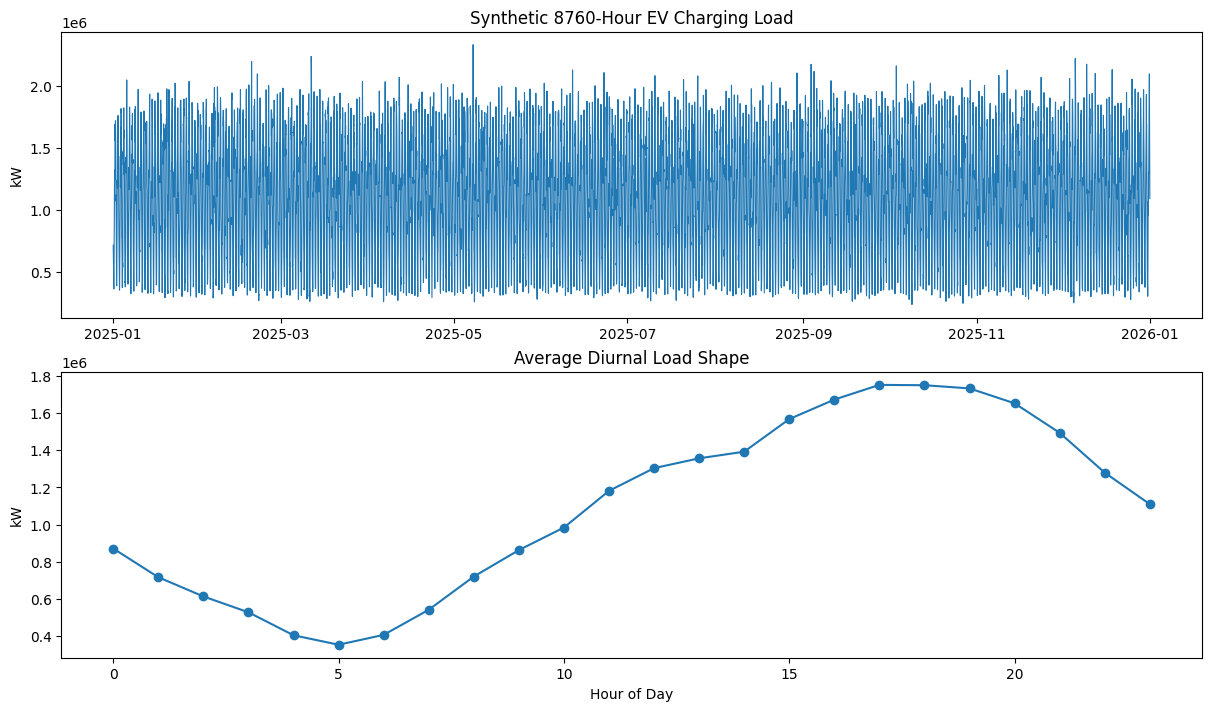

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

axes[0].plot(load_8760["timestamp"], load_8760["synthetic_load_kw"], linewidth=0.8)
axes[0].set_title("Synthetic 8760-Hour EV Charging Load")
axes[0].set_ylabel("kW")

mean_24h = load_8760.groupby(load_8760["timestamp"].dt.hour)["synthetic_load_kw"].mean()
axes[1].plot(mean_24h.index, mean_24h.values, marker="o")
axes[1].set_title("Average Diurnal Load Shape")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("kW")

plt.show()

## 7) Daily-curve ensemble and uncertainty bands

Weekday days plotted: 261
Weekend days plotted: 104


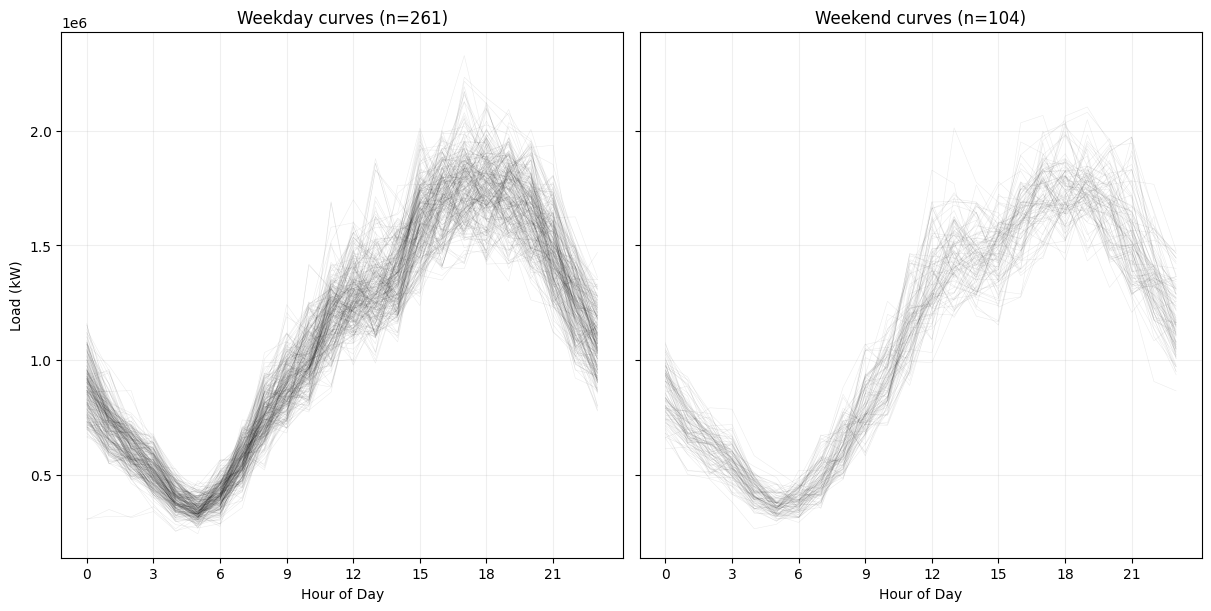

In [9]:
# Plot daily 24-hour curves in two panels: weekday vs weekend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plot_data_path = Path("outputs/synthetic_load_8760.csv")
plot_df = pd.read_csv(plot_data_path)
plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["timestamp", "synthetic_load_kw"]).copy()

plot_df["date"] = plot_df["timestamp"].dt.date
plot_df["hour"] = plot_df["timestamp"].dt.hour
plot_df["day_type"] = np.where(plot_df["timestamp"].dt.dayofweek < 5, "weekday", "weekend")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, constrained_layout=True)

counts = {"weekday": 0, "weekend": 0}
for day_type, ax in zip(["weekday", "weekend"], axes):
    sub = plot_df[plot_df["day_type"] == day_type]
    for _, day_df in sub.groupby("date", sort=True):
        day_df = day_df.sort_values("hour")
        if len(day_df) == 24:
            counts[day_type] += 1
            ax.plot(
                day_df["hour"].to_numpy(),
                day_df["synthetic_load_kw"].to_numpy(),
                color="black",
                linewidth=0.4,
                alpha=0.08,
            )

    ax.set_title(f"{day_type.capitalize()} curves (n={counts[day_type]})")
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(np.arange(0, 24, 3))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Load (kW)")

print(f"Weekday days plotted: {counts['weekday']}")
print(f"Weekend days plotted: {counts['weekend']}")
assert counts["weekday"] + counts["weekend"] == 365, "Total plotted days is not 365"
plt.savefig('outputs/ev_load_daily_curves.png')
plt.show()

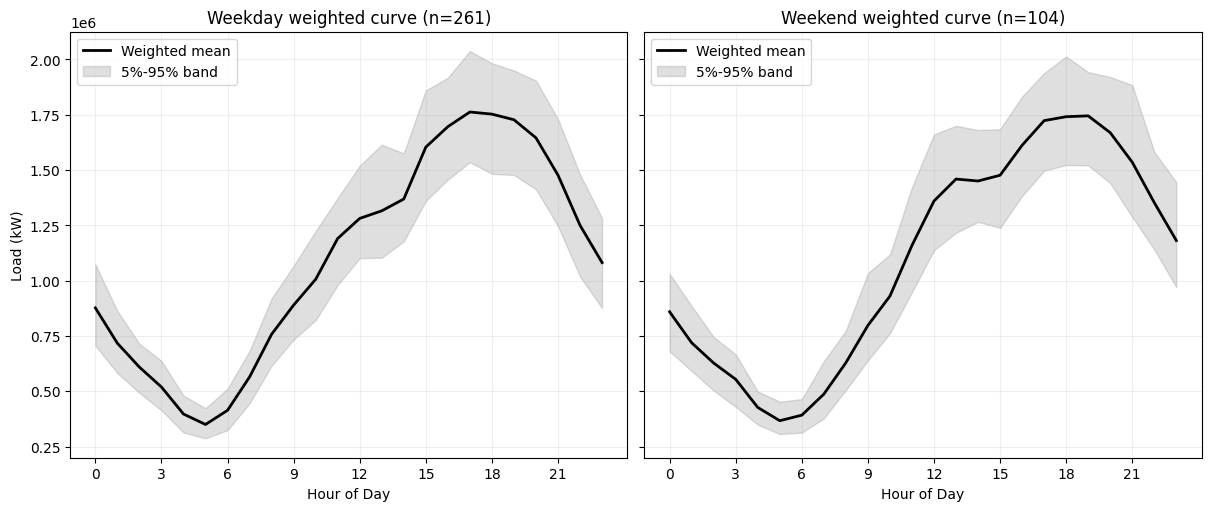

In [10]:
# Weighted average and 5%-95% bands by hour of day, split by weekday/weekend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plot_data_path = Path("outputs/synthetic_load_8760.csv")
plot_df = pd.read_csv(plot_data_path)
plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["timestamp", "synthetic_load_kw"]).copy()
plot_df["date"] = plot_df["timestamp"].dt.date
plot_df["hour"] = plot_df["timestamp"].dt.hour
plot_df["day_type"] = np.where(plot_df["timestamp"].dt.dayofweek < 5, "weekday", "weekend")


def weighted_quantile(values, quantile, sample_weight):
    sorter = np.argsort(values)
    v = values[sorter]
    w = sample_weight[sorter]
    cw = np.cumsum(w)
    return np.interp(quantile, cw, v)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
hours = np.arange(24)

for day_type, ax in zip(["weekday", "weekend"], axes):
    sub = plot_df[plot_df["day_type"] == day_type].copy()
    daily_matrix = []

    for _, day_df in sub.groupby("date", sort=True):
        day_df = day_df.sort_values("hour")
        if len(day_df) == 24:
            daily_matrix.append(day_df["synthetic_load_kw"].to_numpy())

    daily_matrix = np.array(daily_matrix, dtype=float)
    day_weights = np.ones(daily_matrix.shape[0], dtype=float)
    day_weights = day_weights / day_weights.sum()

    mean_hourly = np.average(daily_matrix, axis=0, weights=day_weights)
    q05_hourly = np.array([weighted_quantile(daily_matrix[:, h], 0.05, day_weights) for h in hours])
    q95_hourly = np.array([weighted_quantile(daily_matrix[:, h], 0.95, day_weights) for h in hours])

    ax.plot(hours, mean_hourly, color="black", linewidth=2.0, label="Weighted mean")
    ax.fill_between(hours, q05_hourly, q95_hourly, color="gray", alpha=0.25, label="5%-95% band")

    ax.set_title(f"{day_type.capitalize()} weighted curve (n={daily_matrix.shape[0]})")
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(np.arange(0, 24, 3))
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("Load (kW)")
plt.show()

## Notes

- Stratification labels are `Property.Type`, `Charger.Level`, and `weekday/weekend`.
- Raw share mix is set to: `DCFC 20%`, `Workplace_L2 4%`, `Public_L2 8%`, `Residential_L1_L2 68%`.
- **Residential L1+L2** is generated from the PEV-Profiles dataset (`Data/PEV-Profiles-L1.xlsx` + `Data/PEV-Profiles-L2.xlsx`): each simulated day samples one real fleet-day (matching weekday/weekend) and scales its 24-hour aggregate power shape so the daily kWh equals the residential energy budget. L1 and L2 are combined per timestamp before sampling.
- **DCFC, Workplace_L2, Public_L2** still use the historical session bootstrap: sessions in each `(day_type, raw_share_label)` pool are drawn uniformly per session; `SUPER_SESSION_FACTOR` makes each draw represent multiple identical sessions to widen daily variance while keeping the energy budget on target.
- Missing property-type fallback is applied as requested: Unknown + L1 -> Residential, Unknown + L2 -> Public_L2, Unknown + DC/fast -> DCFC.
- A separate preprocessed tuple dataset is saved to `outputs/session_energy_tuples_with_raw_share.csv` and used by the DCFC / Workplace / Public bootstrap and by the spatial diagnostics.
- Output files are saved under `outputs/`.

## 8) Start-hour composition diagnostic (weekday vs weekend)

Investigate whether specific hours (especially weekday 5-6) have unusual composition by `raw_share_label` in the historical session pool.

Session counts per (day_type, plot_label) - non-residential only:
day_type  plot_label  
weekday   DCFC            2981689
          Public_L2        793116
          Workplace_L2     802158
weekend   DCFC            1149372
          Public_L2        231241
          Workplace_L2      64620

Residential_L1 / Residential_L2 curves below are computed from PEV-Profiles-L1.xlsx / PEV-Profiles-L2.xlsx fleet aggregates (not the per-session tuples).

Peak hour by category:
day_type     plot_label  peak_hour  peak_share
 weekday           DCFC         19      0.0608
 weekday      Public_L2          9      0.0628
 weekday Residential_L1         18      0.0709
 weekday Residential_L2         17      0.0821
 weekday   Workplace_L2          9      0.1126
 weekend           DCFC         19      0.0602
 weekend      Public_L2         14      0.0594
 weekend Residential_L1         18      0.0683
 weekend Residential_L2         17      0.0755
 weekend   Workplace_L2          9      0.0680


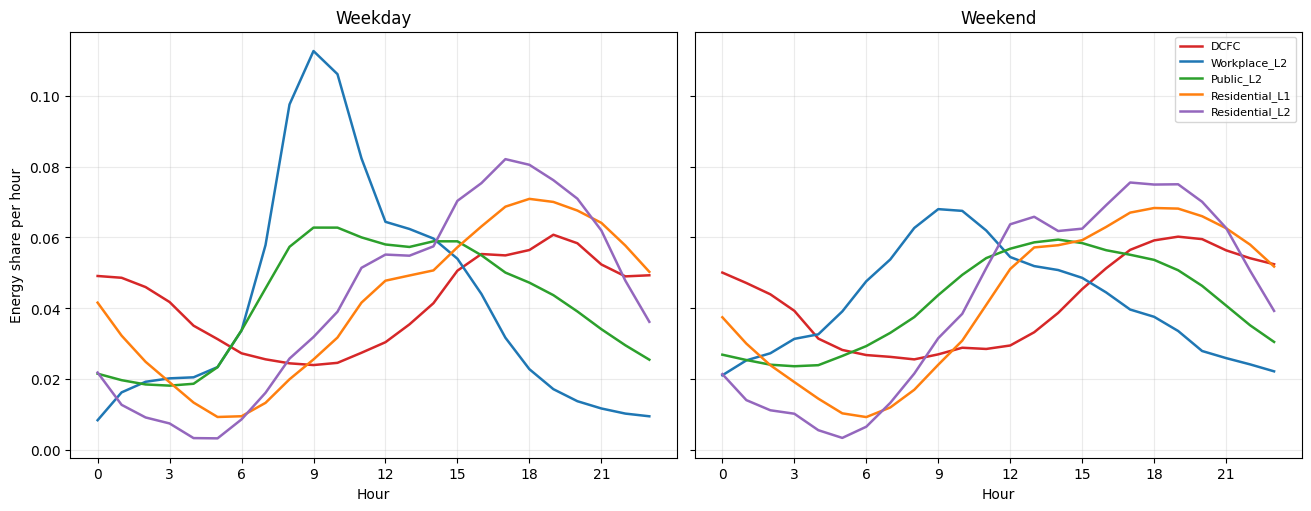

In [11]:
# Diagnose hourly energy distributions per category.
# Each curve is normalized within (day_type, label): sum of 24 hourly shares = 1.
#
# DCFC / Workplace_L2 / Public_L2 are computed from the per-session tuple
# CSV exactly as before (the synthesizer still pools those sessions by
# (day_type, raw_share_label) and samples uniformly per session).
#
# Residential_L1 / Residential_L2 are now computed from the PEV-Profiles
# fleet aggregates (Data/PEV-Profiles-{L1,L2}.xlsx) which are the same
# source the synthesizer's residential branch draws from. This makes the
# diagnostic consistent with what the residential synthesizer actually uses.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

hour_cols = [f"h{h:02d}" for h in range(24)]

if "TUPLE_DATA_PATH" in globals():
    tuple_path = Path(TUPLE_DATA_PATH)
else:
    tuple_path = Path("outputs/session_energy_tuples_with_raw_share.csv")

tuple_df = pd.read_csv(tuple_path)
required_cols = {"day_type", "raw_share_label", *hour_cols}
missing = required_cols.difference(set(tuple_df.columns))
if missing:
    raise ValueError(f"Missing required columns in tuple data: {missing}")

# Non-residential: per-session energy-weighted hourly share from tuples.
non_res = tuple_df[tuple_df["raw_share_label"] != "Residential_L1_L2"].copy()
non_res["plot_label"] = non_res["raw_share_label"].astype(str)
energy_by_label = (
    non_res
    .groupby(["day_type", "plot_label"], dropna=False)[hour_cols]
    .sum()
    .reset_index()
)
row_sums = energy_by_label[hour_cols].sum(axis=1).replace(0, np.nan)
for c in hour_cols:
    energy_by_label[c] = energy_by_label[c] / row_sums
energy_by_label[hour_cols] = energy_by_label[hour_cols].fillna(0.0)


def _pev_shares_by_day_type(profiles):
    """Hourly fleet-power shares (sum=1 per day_type) from a PEV profile dict."""
    wd = profiles["weekday"].fillna(0).to_numpy(dtype=float)
    we = profiles["weekend"].fillna(0).to_numpy(dtype=float)
    wd = wd / wd.sum() if wd.sum() > 0 else wd
    we = we / we.sum() if we.sum() > 0 else we
    return {"weekday": wd, "weekend": we}


pev_l1_shares = _pev_shares_by_day_type(pev_profiles_l1)
pev_l2_shares = _pev_shares_by_day_type(pev_profiles_l2)

residential_rows = []
for day_type in ["weekday", "weekend"]:
    for plot_label, shares in (("Residential_L1", pev_l1_shares),
                               ("Residential_L2", pev_l2_shares)):
        rec = {"day_type": day_type, "plot_label": plot_label}
        for h, c in enumerate(hour_cols):
            rec[c] = float(shares[day_type][h])
        residential_rows.append(rec)
energy_by_label = pd.concat(
    [energy_by_label, pd.DataFrame(residential_rows)], ignore_index=True
)

counts = (
    non_res.groupby(["day_type", "plot_label"], dropna=False).size().rename("sessions")
)
print("Session counts per (day_type, plot_label) - non-residential only:")
print(counts.to_string())
print(
    "\nResidential_L1 / Residential_L2 curves below are computed from "
    "PEV-Profiles-L1.xlsx / PEV-Profiles-L2.xlsx fleet aggregates "
    "(not the per-session tuples)."
)

peak_table = energy_by_label.copy()
peak_table["peak_hour"] = peak_table[hour_cols].idxmax(axis=1).str.lstrip("h").astype(int)
peak_table["peak_share"] = peak_table[hour_cols].max(axis=1).round(4)
print("\nPeak hour by category:")
print(
    peak_table[["day_type", "plot_label", "peak_hour", "peak_share"]]
    .sort_values(["day_type", "plot_label"])
    .to_string(index=False)
)

# Plot: 1 row (per-session weighting only), 2 cols (weekday vs weekend).
preferred_order = [
    "DCFC",
    "Workplace_L2",
    "Public_L2",
    "Residential_L1",
    "Residential_L2",
]
present_labels = set(energy_by_label["plot_label"])
labels = [l for l in preferred_order if l in present_labels] + [
    l for l in present_labels if l not in preferred_order
]

color_map = {
    "DCFC": "#d62728",
    "Workplace_L2": "#1f77b4",
    "Public_L2": "#2ca02c",
    "Residential_L1": "#ff7f0e",
    "Residential_L2": "#9467bd",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
hours = np.arange(24)

for ax, day_type in zip(axes, ["weekday", "weekend"]):
    sub = energy_by_label[energy_by_label["day_type"] == day_type]
    for label in labels:
        row = sub[sub["plot_label"] == label]
        if row.empty:
            continue
        y = row[hour_cols].iloc[0].to_numpy(dtype=float)
        ax.plot(hours, y, linewidth=1.8, label=label, color=color_map.get(label))
    ax.set_title(day_type.capitalize())
    ax.set_xlabel("Hour")
    ax.set_xticks(np.arange(0, 24, 3))
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Energy share per hour")
axes[1].legend(loc="upper right", fontsize=8)
plt.savefig("outputs/ev_load_daily_curves_by_type.png", dpi=120)
plt.show()

## 9) Aggregate vs expected decomposition check

Compare the actual synthesized 8760 aggregate (mean curve by hour) against an
expected aggregate constructed as: for each `raw_share_label`, the normalized
hourly energy share (computed using the same uniform-per-strata weighting as
the synthesizer) is multiplied by that label's daily energy budget and the four
labels are stacked. If everything is consistent, the actual mean curve and the
expected total should overlap, and the aggregate peak should fall on the same
hour as the dominant residential (68%) peak.

Daily budget (kWh) used for expected decomposition:
  - DCFC: 5,250,000
  - Workplace_L2: 1,050,000
  - Public_L2: 2,100,000
  - Residential_L1_L2: 17,850,000


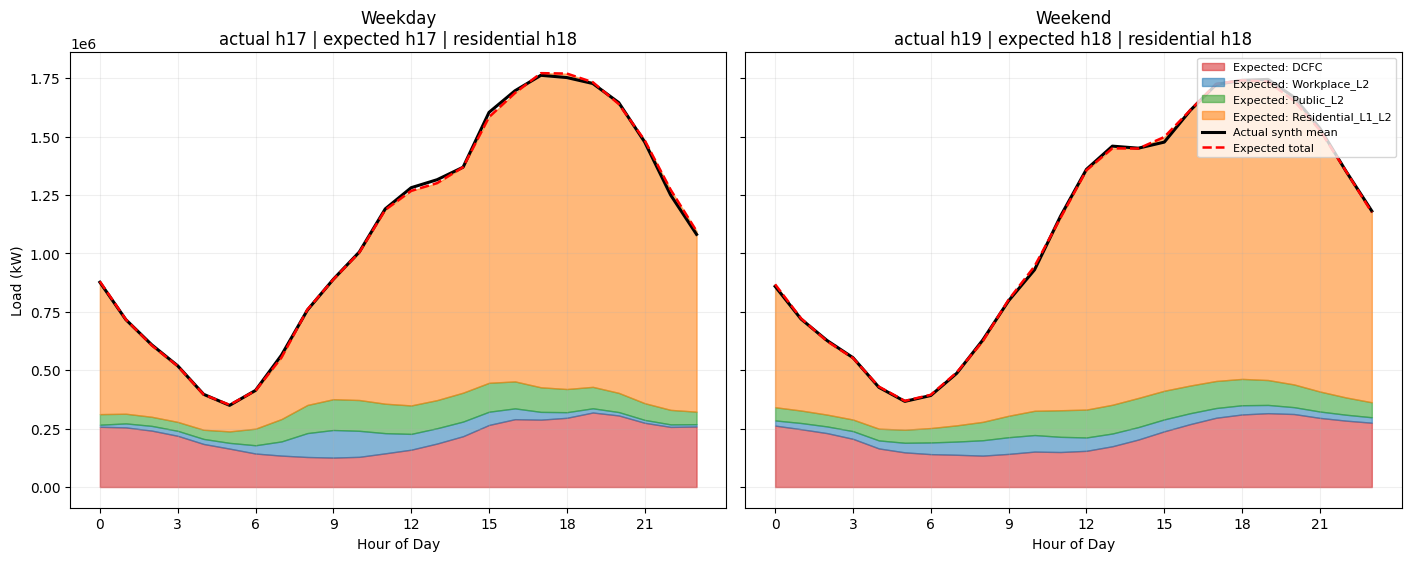


Peak hour comparison:
 - weekday: actual peak h17 | expected peak h17 | residential peak h18
 - weekend: actual peak h19 | expected peak h18 | residential peak h18


In [12]:
# Compare actual synthesized aggregate mean curve vs an expected aggregate
# built per label and scaled by each label's daily kWh budget:
#   - DCFC / Workplace_L2 / Public_L2: per-session, energy-weighted hourly
#     share computed from the tuple CSV (matches the bootstrap sampler that
#     draws every session within a (day_type, raw_share_label) pool with
#     equal probability).
#   - Residential_L1_L2: hourly fleet-power share from the PEV-Profiles
#     combined L1+L2 dataset (matches the residential synthesizer which
#     samples a real fleet-day and scales it to the daily kWh budget).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

hour_cols = [f"h{h:02d}" for h in range(24)]
hours = np.arange(24)

# 1) Actual aggregate from synthesized 8760.
load_path = Path("outputs/synthetic_load_8760.csv")
load_df = pd.read_csv(load_path)
load_df["timestamp"] = pd.to_datetime(load_df["timestamp"], errors="coerce")
load_df = load_df.dropna(subset=["timestamp", "synthetic_load_kw"]).copy()
load_df["hour"] = load_df["timestamp"].dt.hour
load_df["day_type"] = np.where(load_df["timestamp"].dt.dayofweek < 5, "weekday", "weekend")

# 2a) Tuple data -> per-label normalized hourly energy shares for the
#     bootstrap-based categories.
if "TUPLE_DATA_PATH" in globals():
    tuple_path = Path(TUPLE_DATA_PATH)
else:
    tuple_path = Path("outputs/session_energy_tuples_with_raw_share.csv")
tuple_df = pd.read_csv(tuple_path)

bootstrap_labels = ["DCFC", "Workplace_L2", "Public_L2"]
label_uni = (
    tuple_df[tuple_df["raw_share_label"].isin(bootstrap_labels)]
    .groupby(["day_type", "raw_share_label"], dropna=False)[hour_cols]
    .sum()
    .reset_index()
)
row_sums = label_uni[hour_cols].sum(axis=1).replace(0, np.nan)
for c in hour_cols:
    label_uni[c] = label_uni[c] / row_sums
label_uni[hour_cols] = label_uni[hour_cols].fillna(0.0)

# 2b) Residential_L1_L2 shares from PEV-Profiles combined L1 + L2.
res_combo_wd = (pev_profiles_l1["weekday"].fillna(0)
                + pev_profiles_l2["weekday"].fillna(0)).to_numpy(dtype=float)
res_combo_we = (pev_profiles_l1["weekend"].fillna(0)
                + pev_profiles_l2["weekend"].fillna(0)).to_numpy(dtype=float)
res_combo_wd = res_combo_wd / res_combo_wd.sum() if res_combo_wd.sum() > 0 else res_combo_wd
res_combo_we = res_combo_we / res_combo_we.sum() if res_combo_we.sum() > 0 else res_combo_we

res_rows = []
for day_type, shares in (("weekday", res_combo_wd), ("weekend", res_combo_we)):
    rec = {"day_type": day_type, "raw_share_label": "Residential_L1_L2"}
    for h, c in enumerate(hour_cols):
        rec[c] = float(shares[h])
    res_rows.append(rec)
label_uni = pd.concat([label_uni, pd.DataFrame(res_rows)], ignore_index=True)

# 3) Daily budget per label (kWh) - re-derive in case the kernel was restarted.
if "daily_budget" in globals():
    budget = dict(daily_budget)
else:
    raw_shares = {"DCFC": 0.20, "Workplace_L2": 0.04, "Public_L2": 0.08, "Residential_L1_L2": 0.68}
    share_sum = sum(raw_shares.values())
    daily_total = 2_500_000 * 35.0 * 0.30
    budget = {k: daily_total * (v / share_sum) for k, v in raw_shares.items()}

print("Daily budget (kWh) used for expected decomposition:")
for k, v in budget.items():
    print(f"  - {k}: {v:,.0f}")

# 4) Build expected per-label kW per hour: share * label_budget_kwh / 1h
expected_rows = []
for _, row in label_uni.iterrows():
    label = row["raw_share_label"]
    if label not in budget:
        continue
    kw_24 = row[hour_cols].to_numpy(dtype=float) * float(budget[label])
    rec = {"day_type": row["day_type"], "raw_share_label": label}
    for h in range(24):
        rec[f"h{h:02d}"] = kw_24[h]
    expected_rows.append(rec)
expected_df = pd.DataFrame(expected_rows)

# 5) Plot stacked expected per-label + actual aggregate mean, for weekday/weekend.
label_order = ["DCFC", "Workplace_L2", "Public_L2", "Residential_L1_L2"]
colors = {
    "DCFC": "#d62728",
    "Workplace_L2": "#1f77b4",
    "Public_L2": "#2ca02c",
    "Residential_L1_L2": "#ff7f0e",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True, constrained_layout=True)

peak_lines = []
for day_type, ax in zip(["weekday", "weekend"], axes):
    sub = expected_df[expected_df["day_type"] == day_type].set_index("raw_share_label")
    cumulative = np.zeros(24)
    for label in label_order:
        if label not in sub.index:
            continue
        vals = sub.loc[label, hour_cols].to_numpy(dtype=float)
        ax.fill_between(
            hours, cumulative, cumulative + vals,
            label=f"Expected: {label}", color=colors.get(label), alpha=0.55,
        )
        cumulative += vals
    expected_total = cumulative.copy()

    sub_load = load_df[load_df["day_type"] == day_type]
    actual_mean = sub_load.groupby("hour")["synthetic_load_kw"].mean().reindex(hours).to_numpy()

    ax.plot(hours, actual_mean, color="black", linewidth=2.2, label="Actual synth mean")
    ax.plot(hours, expected_total, color="red", linewidth=1.8, linestyle="--", label="Expected total")

    actual_peak = int(np.argmax(actual_mean))
    expected_peak = int(np.argmax(expected_total))
    res_curve = sub.loc["Residential_L1_L2", hour_cols].to_numpy(dtype=float) if "Residential_L1_L2" in sub.index else np.zeros(24)
    res_peak = int(np.argmax(res_curve))

    peak_lines.append(
        f"{day_type}: actual peak h{actual_peak:02d} | expected peak h{expected_peak:02d} | residential peak h{res_peak:02d}"
    )

    ax.set_title(
        f"{day_type.capitalize()}\n"
        f"actual h{actual_peak:02d} | expected h{expected_peak:02d} | residential h{res_peak:02d}"
    )
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(np.arange(0, 24, 3))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Load (kW)")
axes[1].legend(loc="upper right", fontsize=8)
plt.savefig("outputs/aggregate_vs_expected_decomposition.png", dpi=120)
plt.show()

print("\nPeak hour comparison:")
for line in peak_lines:
    print(" -", line)

## 10) Spatial distribution of sessions (county / census tract)

Choropleth maps showing how the raw historical sessions are distributed across California counties and census tracts. Each session is geolocated via its `GEOID` (11-digit census tract FIPS); the first five digits are the county FIPS.

Two maps are produced side by side:

- **Left**: session count per CA county
- **Right**: session count per CA census tract

A log color scale is used because the distribution is highly skewed (most sessions concentrate in Bay Area / LA county tracts). Geographic units with no observed sessions are shown in light gray.

TIGER/Line 2020 boundary shapefiles are downloaded once and cached under `outputs/geo_cache/`.

Sessions with valid GEOID: 6,124,834 / 6,404,294
Counties with sessions: 40
Tracts with sessions:   634


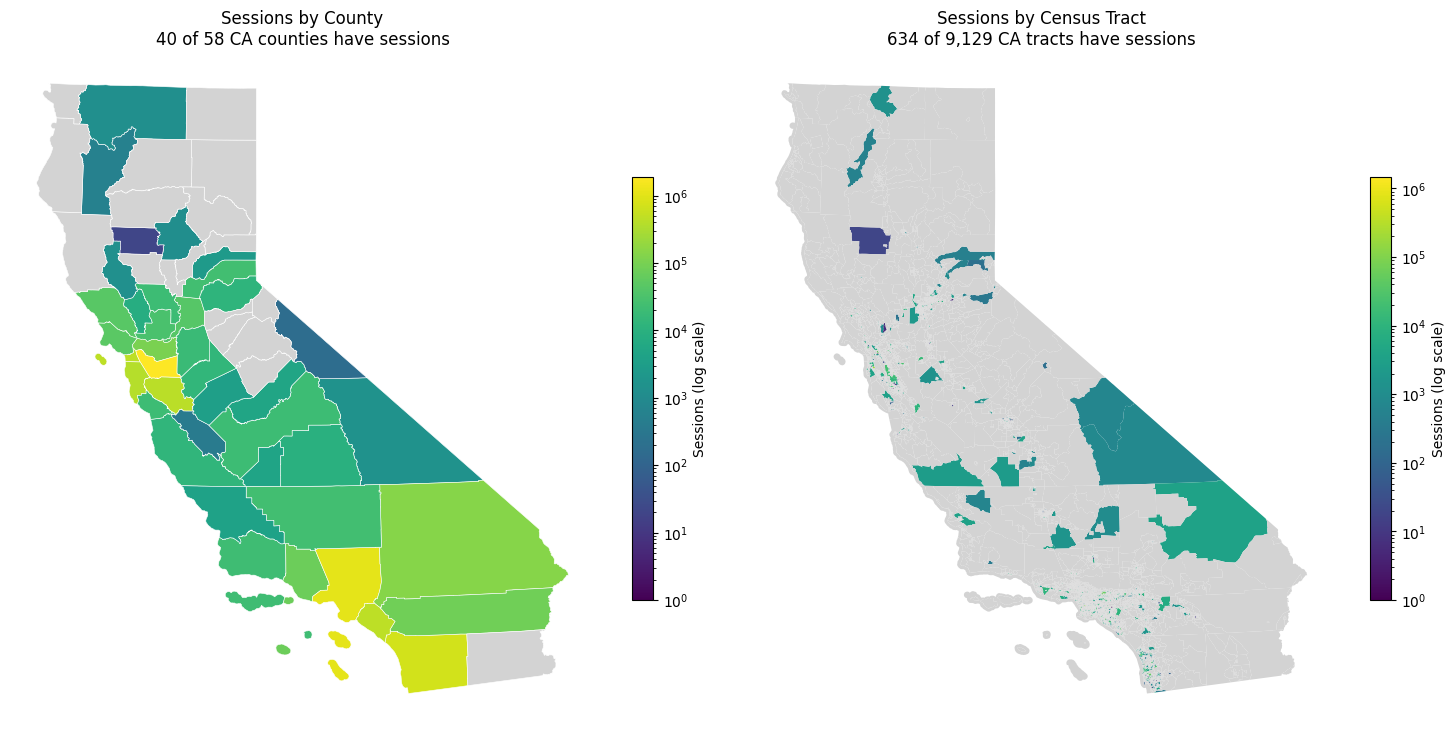


Saved: E:\GitHub\EV_LCA\outputs\session_distribution_maps.png

Top 10 counties by session count:
        county county_fips  sessions  share_%
       Alameda       06001   1911440    31.21
   Los Angeles       06037   1029674    16.81
     San Diego       06073    696884    11.38
        Orange       06059    456162     7.45
 San Francisco       06075    448647     7.33
   Santa Clara       06085    416168     6.79
     San Mateo       06081    375308     6.13
San Bernardino       06071    134916     2.20
  Contra Costa       06013    103181     1.68
     Riverside       06065     84724     1.38


In [13]:
import urllib.request

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1) Aggregate session counts per county (5-digit FIPS) and tract (11-digit FIPS).
geo_df = pd.read_csv(DATA_PATH, usecols=["GEOID"], low_memory=False)
n_total = len(geo_df)
geo_df = geo_df.dropna(subset=["GEOID"]).copy()
geo_df["tract_geoid"] = geo_df["GEOID"].astype(np.int64).astype(str).str.zfill(11)
geo_df["county_geoid"] = geo_df["tract_geoid"].str[:5]
print(f"Sessions with valid GEOID: {len(geo_df):,} / {n_total:,}")

county_counts = (
    geo_df.groupby("county_geoid").size().rename("sessions").reset_index()
)
tract_counts = (
    geo_df.groupby("tract_geoid").size().rename("sessions").reset_index()
)
print(f"Counties with sessions: {len(county_counts):,}")
print(f"Tracts with sessions:   {len(tract_counts):,}")

# 2) Fetch + cache TIGER/Line 2020 boundary shapefiles.
GEO_CACHE = OUTPUT_DIR / "geo_cache"
GEO_CACHE.mkdir(parents=True, exist_ok=True)


def _fetch_zip(url, name):
    path = GEO_CACHE / name
    if not path.exists():
        print(f"Downloading {url}")
        urllib.request.urlretrieve(url, path)
    return path


counties_zip = _fetch_zip(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip",
    "tl_2020_us_county.zip",
)
tracts_zip = _fetch_zip(
    "https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_06_tract.zip",
    "tl_2020_06_tract.zip",
)

counties_gdf = gpd.read_file(counties_zip)
tracts_gdf = gpd.read_file(tracts_zip)

# 3) Filter to California, merge in session counts, project to CA Albers (EPSG:3310).
ca_counties = counties_gdf[counties_gdf["STATEFP"] == "06"].copy()
ca_counties = ca_counties.merge(
    county_counts, left_on="GEOID", right_on="county_geoid", how="left"
)
ca_tracts = tracts_gdf.merge(
    tract_counts, left_on="GEOID", right_on="tract_geoid", how="left"
)

ca_counties = ca_counties.to_crs("EPSG:3310")
ca_tracts = ca_tracts.to_crs("EPSG:3310")

# 4) Plot side-by-side choropleths with a shared log color scale per panel.
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

county_vmax = int(ca_counties["sessions"].max())
tract_vmax = int(ca_tracts["sessions"].max())

ca_counties.plot(
    column="sessions",
    cmap="viridis",
    legend=True,
    norm=LogNorm(vmin=1, vmax=county_vmax),
    edgecolor="white",
    linewidth=0.4,
    ax=axes[0],
    missing_kwds={"color": "lightgray", "label": "No sessions"},
    legend_kwds={"label": "Sessions (log scale)", "shrink": 0.55},
)
n_county_with = int((ca_counties["sessions"] > 0).sum())
axes[0].set_title(
    f"Sessions by County\n{n_county_with:,} of {len(ca_counties):,} CA counties have sessions"
)
axes[0].set_axis_off()

ca_tracts.plot(
    column="sessions",
    cmap="viridis",
    legend=True,
    norm=LogNorm(vmin=1, vmax=tract_vmax),
    edgecolor="none",
    ax=axes[1],
    missing_kwds={"color": "lightgray", "label": "No sessions"},
    legend_kwds={"label": "Sessions (log scale)", "shrink": 0.55},
)
n_tract_with = int((ca_tracts["sessions"] > 0).sum())
axes[1].set_title(
    f"Sessions by Census Tract\n{n_tract_with:,} of {len(ca_tracts):,} CA tracts have sessions"
)
axes[1].set_axis_off()

plt.tight_layout()
out_path = OUTPUT_DIR / "session_distribution_maps.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_path.resolve()}")

# 5) Tabular summary of top counties.
total_sessions = float(county_counts["sessions"].sum())
top_counties = (
    ca_counties.dropna(subset=["sessions"])
    .nlargest(10, "sessions")[["NAME", "GEOID", "sessions"]]
    .rename(columns={"NAME": "county", "GEOID": "county_fips"})
    .reset_index(drop=True)
)
top_counties["sessions"] = top_counties["sessions"].astype(int)
top_counties["share_%"] = (100 * top_counties["sessions"] / total_sessions).round(2)
print("\nTop 10 counties by session count:")
print(top_counties.to_string(index=False))

## 11) Spatial distribution by category (DCFC / Workplace / Public / Residential)

Per-`raw_share_label` choropleths showing where each charging category's historical sessions are concentrated. One row per category, with the county-level map on the left and the census-tract map on the right. Each panel uses an independent log color scale so the spatial pattern is visible even when absolute counts differ by orders of magnitude across categories.

Reuses the in-memory `df` (now carrying `GEOID` from cell 2) and the CA county/tract geometries loaded by the previous cell.

Plotting per-label maps for: ['DCFC', 'Workplace_L2', 'Public_L2', 'Residential_L1_L2']


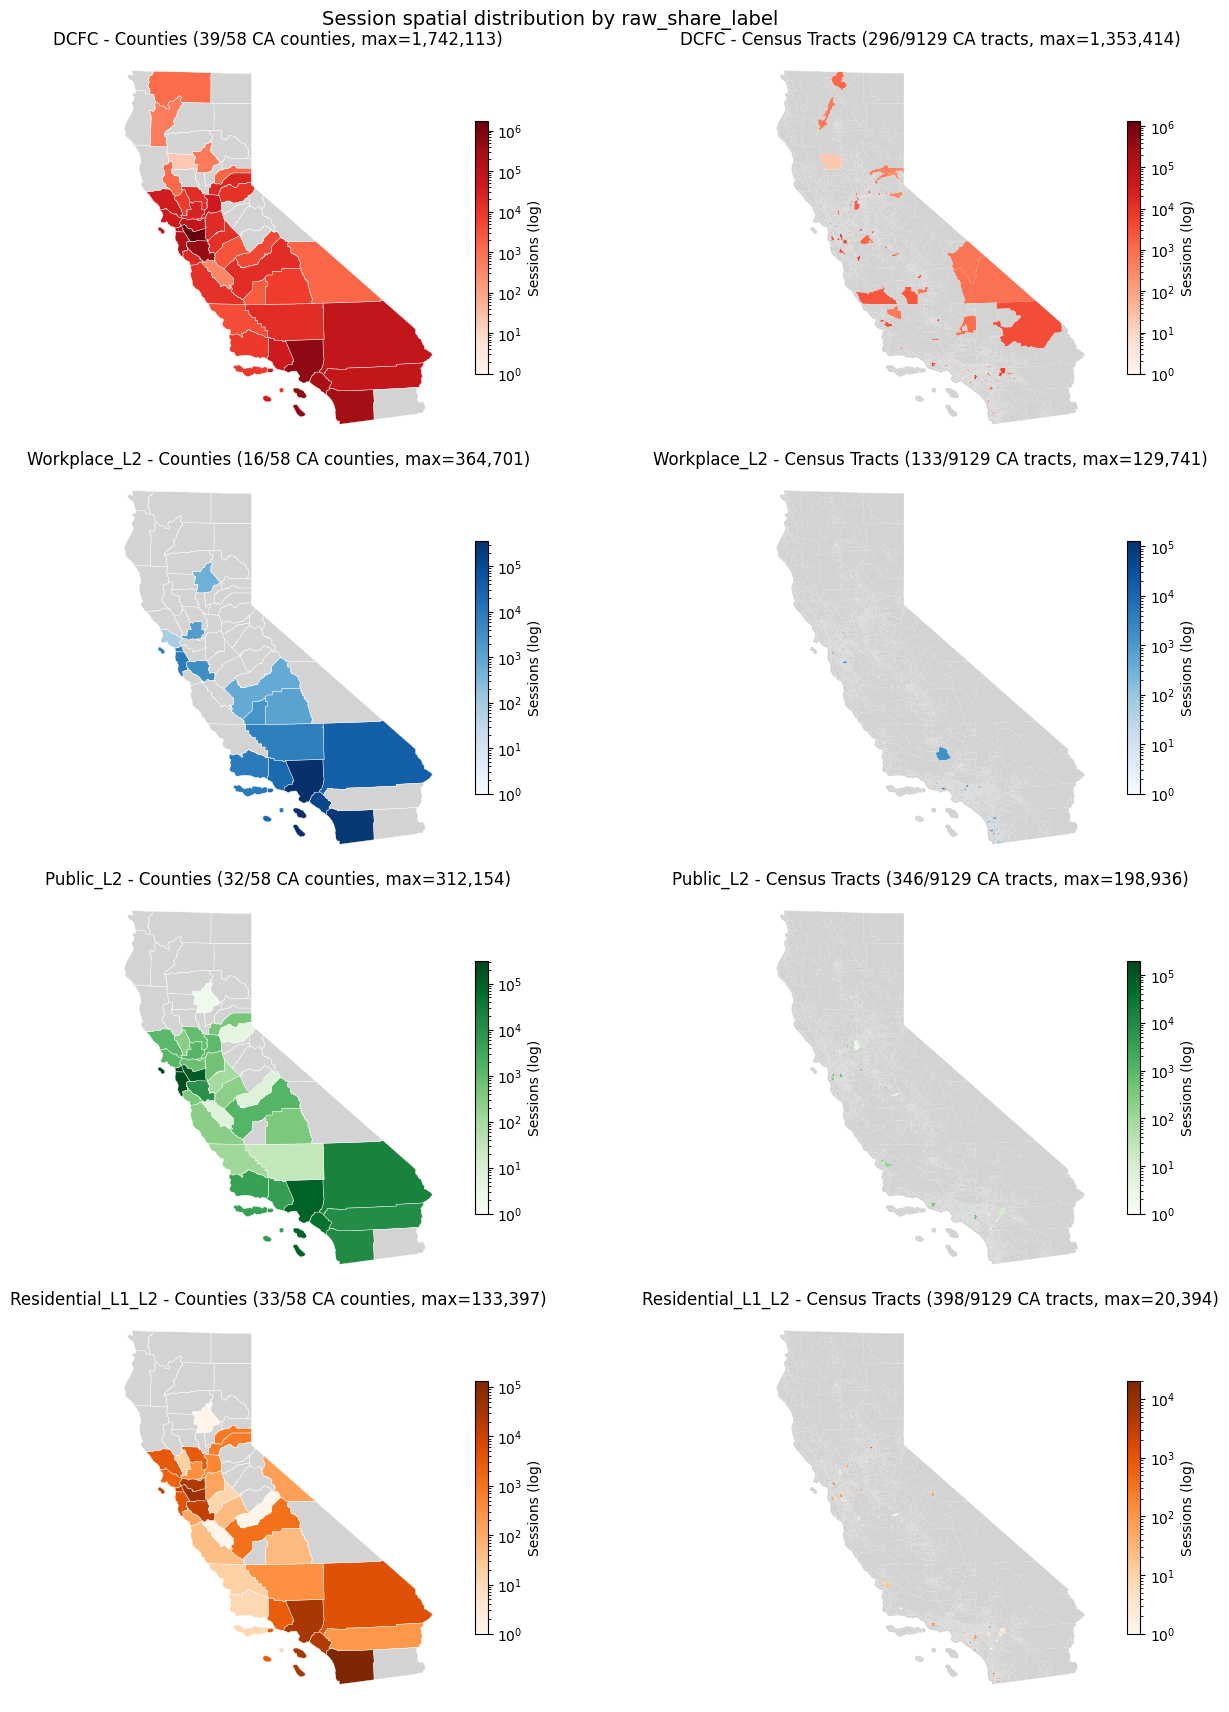


Saved: E:\GitHub\EV_LCA\outputs\session_distribution_maps_by_label.png

Session coverage by raw_share_label:
                   sessions  share_%  counties_with_sessions  tracts_with_sessions
raw_share_label                                                                   
DCFC                4090368    66.78                      39                   296
Public_L2            882773    14.41                      32                   346
Residential_L1_L2    297133     4.85                      33                   398
Workplace_L2         854560    13.95                      16                   133


In [14]:
# Ensure GEOID is available on df. Cell 2 ("Load and preprocess") now reads
# GEOID into df by default, but if df was built before that change (or with a
# narrower usecols), load it here from the CSV and align on the original row
# index (filtering in cell 2 preserves the original index, so pandas can align
# the Series automatically).
if "GEOID" not in df.columns:
    print("GEOID missing from df; loading from CSV and aligning by index.")
    df["GEOID"] = pd.read_csv(DATA_PATH, usecols=["GEOID"], low_memory=False)["GEOID"]

# Aggregate session counts per (raw_share_label, county) and (raw_share_label, tract).
geo_label_df = df[["GEOID", "raw_share_label"]].dropna(subset=["GEOID"]).copy()
geo_label_df["tract_geoid"] = (
    geo_label_df["GEOID"].astype(np.int64).astype(str).str.zfill(11)
)
geo_label_df["county_geoid"] = geo_label_df["tract_geoid"].str[:5]

county_by_label = (
    geo_label_df.groupby(["raw_share_label", "county_geoid"])
    .size().rename("sessions").reset_index()
)
tract_by_label = (
    geo_label_df.groupby(["raw_share_label", "tract_geoid"])
    .size().rename("sessions").reset_index()
)

# Plot in the order from RAW_SHARES (skip categories with no sessions).
labels_to_plot = [lbl for lbl in RAW_SHARES.keys() if (geo_label_df["raw_share_label"] == lbl).any()]
print(f"Plotting per-label maps for: {labels_to_plot}")

# Bare geometries (drop merged columns from the previous cell).
county_geom = ca_counties[["GEOID", "NAME", "geometry"]].copy()
tract_geom = ca_tracts[["GEOID", "geometry"]].copy()

# A distinct colormap per category for easier visual separation.
cmap_by_label = {
    "DCFC": "Reds",
    "Workplace_L2": "Blues",
    "Public_L2": "Greens",
    "Residential_L1_L2": "Oranges",
}

n_rows = len(labels_to_plot)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4.2 * n_rows), constrained_layout=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for i, lbl in enumerate(labels_to_plot):
    cmap = cmap_by_label.get(lbl, "viridis")

    cdf = county_by_label[county_by_label["raw_share_label"] == lbl]
    tdf = tract_by_label[tract_by_label["raw_share_label"] == lbl]

    cmerged = county_geom.merge(cdf, left_on="GEOID", right_on="county_geoid", how="left")
    tmerged = tract_geom.merge(tdf, left_on="GEOID", right_on="tract_geoid", how="left")

    c_vmax = max(int(cmerged["sessions"].max() or 1), 1)
    t_vmax = max(int(tmerged["sessions"].max() or 1), 1)

    cmerged.plot(
        column="sessions", cmap=cmap, legend=True,
        norm=LogNorm(vmin=1, vmax=c_vmax),
        edgecolor="white", linewidth=0.3, ax=axes[i, 0],
        missing_kwds={"color": "lightgray"},
        legend_kwds={"label": "Sessions (log)", "shrink": 0.65},
    )
    n_c = int((cmerged["sessions"] > 0).sum())
    axes[i, 0].set_title(
        f"{lbl} - Counties ({n_c}/{len(cmerged)} CA counties, max={c_vmax:,})"
    )
    axes[i, 0].set_axis_off()

    tmerged.plot(
        column="sessions", cmap=cmap, legend=True,
        norm=LogNorm(vmin=1, vmax=t_vmax),
        edgecolor="none", ax=axes[i, 1],
        missing_kwds={"color": "lightgray"},
        legend_kwds={"label": "Sessions (log)", "shrink": 0.65},
    )
    n_t = int((tmerged["sessions"] > 0).sum())
    axes[i, 1].set_title(
        f"{lbl} - Census Tracts ({n_t}/{len(tmerged)} CA tracts, max={t_vmax:,})"
    )
    axes[i, 1].set_axis_off()

fig.suptitle("Session spatial distribution by raw_share_label", fontsize=14, y=1.01)

out_path = OUTPUT_DIR / "session_distribution_maps_by_label.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_path.resolve()}")

# Tabular summary: overall share and county/tract coverage per category.
total_by_label = geo_label_df.groupby("raw_share_label").size().rename("sessions")
share = (100 * total_by_label / total_by_label.sum()).round(2)
coverage = pd.DataFrame({
    "sessions": total_by_label.astype(int),
    "share_%": share,
    "counties_with_sessions": county_by_label.groupby("raw_share_label").size(),
    "tracts_with_sessions": tract_by_label.groupby("raw_share_label").size(),
}).fillna(0).astype({"counties_with_sessions": int, "tracts_with_sessions": int})
print("\nSession coverage by raw_share_label:")
print(coverage.to_string())